# Does Balance of Power actually "lead" price? ⚖️
### A buyers-vs-sellers gauge — green bar vs red bar — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_buyer/seller_balance_forecast%3F: Busted](https://img.shields.io/badge/Does_buyer%2Fseller_balance_forecast%3F-Busted-8b949e?style=flat-square)

Open many charting packages and you'll find **Balance of Power** (Igor Livshin, 2001): for every bar it measures **(close − open) / (high − low)** — how much of the day's range the buyers captured. A bar that closes near its high scores near **+1** (buyers won the day); near its low, near **−1** (sellers won). Smooth that over a couple of weeks and the lore says you get a **lead on price**: when smoothed BOP turns positive — buyers taking control — a rise is coming. So you **buy the up-cross.**

It *sounds* mechanical and sober. But "the side that won today keeps winning tomorrow" is exactly the kind of momentum story that an upward-drifting market fakes for free. So we did the only fair thing: encode the rule **mechanically**, fire the "buy when smoothed BOP crosses up through zero" trade **1,631 times** across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from balance_of_power import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real BOP cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1631, 'smooth': 14, 'fp_spy': '4cb5244f3990', 'h5': (5, 1626, 17.8, 57, 2.37, 13.9, 3.9, 15.8, 0.42, 0.678), 'h10': (10, 1626, 39.8, 59, 3.57, 36.5, 3.2, 37.8, 0.26, 0.798), 'h20': (20, 1624, 73.9, 59, 4.08, 81.8, -7.9, 71.9, -0.43, 0.666), 'h60': (60, 1617, 273.7, 68, 6.13, 306.3, -32.6, 271.7, -1.08, 0.281), 'per': [('SPY', 304, 23.6, 0.61, 105.4, -81.8), ('QQQ', 320, 104.2, 2.84, 130.5, -26.4), ('IWM', 382, 66.2, 1.51, 6.1, 60.1), ('DIA', 316, 55.2, 1.69, 65.9, -10.7), ('GLD', 309, 120.6, 3.12, 118.3, 2.3)], 'placebo': (23.6, 0.994, 500), 'syn': [(0.0, 238, 5.7, 50, 0.14), (1.5, 129, 281.7, 69, 3.19)]}


real BOP cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when smoothed BOP turns positive, do I make money? | **Yes — but only because the market goes up.** The win-rate is ~59% and the returns look great. |
| Is that *the indicator's* doing? | **No.** Buy on **random days** instead and you do **just as well or better** — at 20 and 60 days the BOP cross is actually *worse* than a coin-flip entry. |
| Does buyer/seller balance *forecast*? | **Not in any usable way.** Scramble the order of the BOP readings into nonsense and the result barely changes (in fact it gets *better*). The sequence isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a buyer-strength signal. |

> Balance of Power is a fine way to *describe* who won a given bar. As a *forecast* — "buyers winning today means a rise tomorrow" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the indicator.

## 1 · The claim

> *"For each bar, BOP = (close − open) / (high − low) — the share of the range the buyers took. Smooth it. When smoothed BOP crosses **up** through zero, buyers have seized control and price will follow. Buy the up-cross."*

This is **Igor Livshin's** Balance of Power (*Stocks & Commodities*, 2001), built into many charting suites under his name. The pitch is that BOP measures the *strength* behind a move and so anticipates continuation — a clean, formula-driven read on supply and demand. So: does the balance actually *lead*?

## 2 · So what?

If smoothed BOP genuinely *forecast* the next move, it would be remarkable: a backward-looking average of where bars closed would predict future direction — a crack in market efficiency you could trade with a one-line formula. That's the dream the indicator sells.

But there's a trap. The rule is **long-only** and it fires on a market (stock indices) that drifts **up** over time, so *any* "buy" rule will look profitable. And "the side that won today keeps winning" is just momentum — which an upward-drifting tape manufactures for free. To separate the **indicator** from the **tide**, we have to (a) read BOP causally with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute BOP each bar** — (close − open) / (high − low), how much of the range buyers took.
2. **Smooth it** with a **14-day** trailing average (causal — only past bars), so no future data leaks in.
3. **Trade the lore.** When smoothed BOP **crosses up through zero**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the indicator leads, the up-cross must beat random. *If it doesn't, the signal is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does smoothed BOP even look like, and where does the rule buy? Here's SPY with its smoothed Balance of Power below and the zero up-crosses the rule would buy.

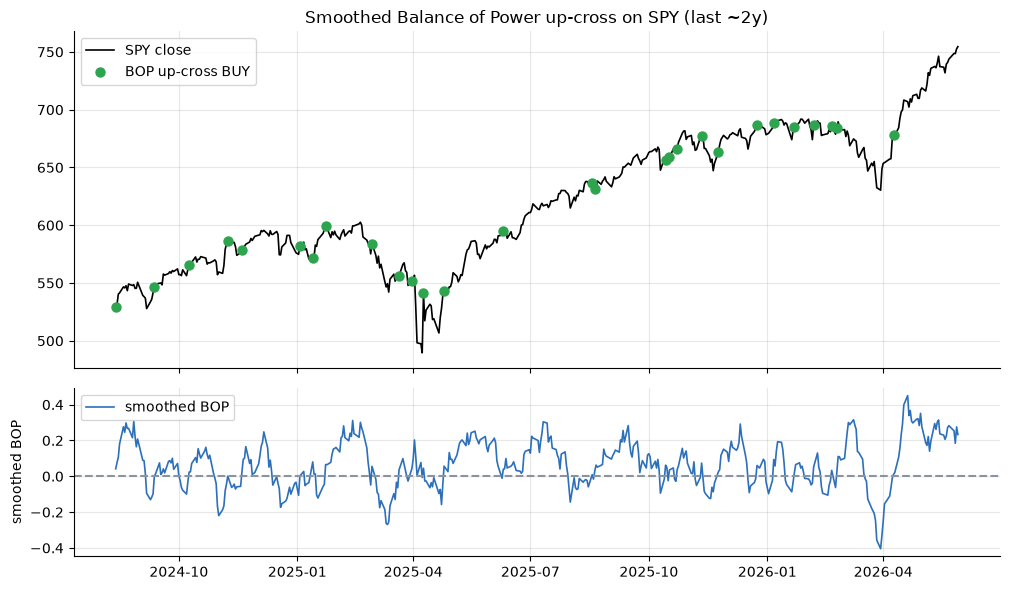

BOP up-crosses in window: 28


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    sb = st.smoothed_bop(b, smooth=R['smooth'])
    ent = st.bop_cross_entries(b, smooth=R['smooth'])
    ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=42, zorder=5, label='BOP up-cross BUY')
    ax1.set_title('Smoothed Balance of Power up-cross on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, sb.reindex(seg.index), c='#2c6fbb', lw=1.2, label='smoothed BOP')
    ax2.axhline(0, c=GREY, ls='--'); ax2.set_ylabel('smoothed BOP'); ax2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('BOP up-crosses in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The cross fires whenever the smoothed buyer/seller balance flips from negative to positive. The question is whether those green buy dots are followed by *more* of a rise than you'd get anyway. **Let's race the BOP up-cross against random entries** at four horizons. Blue = buy the up-cross; grey = buy on random days.

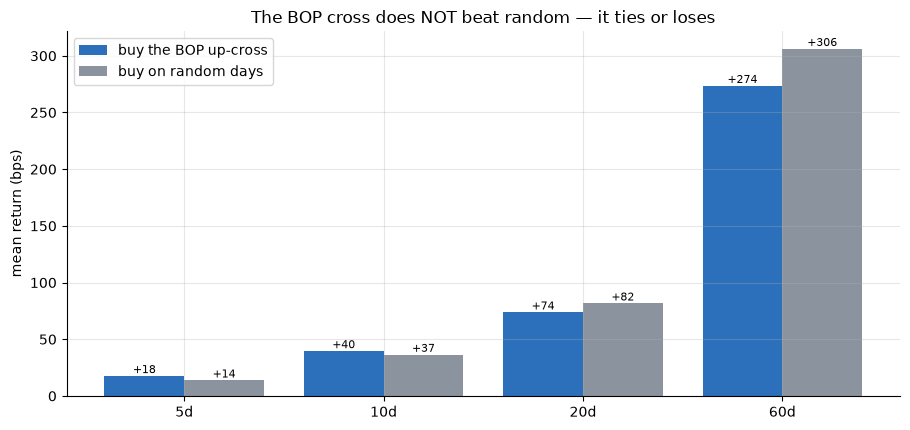

cross: [18, 40, 74, 274]
random: [14, 37, 82, 306]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.bop_cross_entries(bb, smooth=R['smooth'])
            re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the BOP up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The BOP cross does NOT beat random — it ties or loses'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The BOP cross makes money in absolute terms (**+74 bps** over 20 days) — but **random entries make as much or more** (**+82 bps** at 20d). At 20 and 60 days the indicator is *worse* than throwing darts; at 5 and 10 days it's a dead heat. The apparent edge was **the market's upward drift**, not the buyer/seller balance.

**One more sanity check.** What if we **scramble the order** of the BOP readings — keep the same set of values but shuffle when they occurred, so the smoothed line and its crosses become temporally meaningless? If BOP really *leads* price, the nonsense version should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.scramble_placebo(load('SPY'), 20, smooth=R['smooth'], n_draws=300, seed=473)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real BOP up-cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *time-scrambled* BOP series do at least as well (p={pval:.2f}).')
print('=> the order of the buyer/seller readings is not doing the work.')

real BOP up-cross (SPY, 20d): +23.6 bps
... but 99% of *time-scrambled* BOP series do at least as well (p=0.99).
=> the order of the buyer/seller readings is not doing the work.


Almost **all** of the **scrambled** BOP series match or beat the real one (*p* = 0.99). If buyer/seller balance genuinely *led* price, a random time-scramble would collapse the result. It doesn't — because the result was never about the balance.

## 5 · The verdict

- **Signal — None.** The BOP up-cross does **not** beat buying on random days (it ties at 5–10 days and is *worse* at 20–60; the cross-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the indicator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **Does buyer/seller balance forecast? — Busted.** Scramble the order of the readings into nonsense and the result *improves*. The balance doesn't lead.

## 6 · Could you actually trade it?

There's nothing here to trade. The BOP cross's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The cross trades *less* of the time and pays costs on every signal, so it's a worse, more expensive way to be long. As a forecasting tool it doesn't pay; as a buyer/seller read-out it was never built to predict the next bar.

## 7 · Going further 🚪

- **Other thresholds.** Try a slope rule, a higher BOP threshold, or an EMA smoothing — the result is robust: drift in, indicator out.
- **The whole oscillator family.** Chaikin Money Flow, Force Index, Accumulation/Distribution and the Klinger oscillator all chase the same "who's in control" intuition and land in the same place.
- **A real positive control.** The quants notebook plants a *genuine* BOP-leads-price structure into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think buyer/seller balance forecasts? Show the BOP up-cross beating random entries at **t ≥ 2** on a real tape — then we'll talk.*